In [15]:
!pip install imbalanced-learn

In [18]:
'''Q1. Split into train and test first, stratified on the target, with a fixed random_state. Write two lines on why this is the first step and not a later one.'''
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import skew
from sklearn.model_selection import train_test_split

df = pd.read_csv('/cardekho.csv')

df.columns = df.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip().str.lower()
df = df.rename(columns={'fuel_type': 'fuel', 'transmission_type': 'transmission', 'car_name': 'name'})
print(df.columns.tolist())

for c in ['mileage', 'engine', 'max_power']:
    df[c] = pd.to_numeric(df[c].astype(str).str.extract(r'([\d.]+)')[0], errors='coerce')

if 'name' in df.columns:
    df['brand'] = df['name'].str.split().str[0]
    df['model'] = df['name'].str.split().str[:2].str.join(' ')

df['high_price'] = (df['selling_price'] >= 1_000_000).astype(int)
df = df.drop(columns=['name', 'selling_price', 'torque', 'unnamed: 0'], errors='ignore')

y = df['high_price']
X = df.drop(columns=['high_price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(df.shape)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3).to_dict(), y_test.value_counts(normalize=True).round(3).to_dict())
print('Splitting first means the test set is never seen by any imputer, scaler, encoder or sampler, so it behaves like truly new data.')
print('Any statistic computed before the split lets test information leak into training and makes the final score look better than it is.')

['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
(8128, 13)
(6502, 12) (1626, 12)
{0: 0.893, 1: 0.107} {0: 0.893, 1: 0.107}
Splitting first means the test set is never seen by any imputer, scaler, encoder or sampler, so it behaves like truly new data.
Any statistic computed before the split lets test information leak into training and makes the final score look better than it is.


In [19]:
'''Q2. Handle missing values three ways: drop the rows, fill with mean or median, and use KNNImputer. Fit each on the training set only. Compare the mean and standard deviation of one affected column across the three results and say which you would keep.'''
from sklearn.impute import SimpleImputer, KNNImputer

num_cols = [c for c in ['year', 'km_driven', 'vehicle_age', 'mileage', 'engine', 'max_power', 'seats'] if c in X_train.columns]
missing = X_train[num_cols].isna().sum()
print(missing)

col = missing.idxmax()
print('Affected column used for comparison:', col)

dropped = X_train[num_cols].dropna()

median_imp = SimpleImputer(strategy='median').fit(X_train[num_cols])
filled = pd.DataFrame(median_imp.transform(X_train[num_cols]), columns=num_cols, index=X_train.index)

knn_imp = KNNImputer(n_neighbors=5).fit(X_train[num_cols])
knn_filled = pd.DataFrame(knn_imp.transform(X_train[num_cols]), columns=num_cols, index=X_train.index)

comparison = pd.DataFrame({
    'rows': [len(X_train[col].dropna()), len(dropped), len(filled), len(knn_filled)],
    'mean': [X_train[col].mean(), dropped[col].mean(), filled[col].mean(), knn_filled[col].mean()],
    'std': [X_train[col].std(), dropped[col].std(), filled[col].std(), knn_filled[col].std()]
}, index=['original (non-missing only)', 'drop rows', 'median fill', 'KNN imputer'])
print(comparison.round(3))
print('I would keep median imputation: it keeps every row, leaves the mean almost unchanged, and fits inside a pipeline cheaply.')

year           0
km_driven      0
mileage      183
engine       183
max_power    177
seats        183
dtype: int64
Affected column used for comparison: mileage
                             rows    mean    std
original (non-missing only)  6319  19.394  4.020
drop rows                    6319  19.394  4.020
median fill                  6502  19.391  3.963
KNN imputer                  6502  19.349  3.987
I would keep median imputation: it keeps every row, leaves the mean almost unchanged, and fits inside a pipeline cheaply.


In [20]:
'''Q3. Flag outliers in a numeric column by the IQR rule, by the z-score rule, and by capping at the 1st and 99th percentile. Report how many rows each method flags, how much they overlap, and which one you chose.'''
col = 'km_driven'
s = X_train[col]

q1, q3 = s.quantile(0.25), s.quantile(0.75)
iqr = q3 - q1
iqr_mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

z = (s - s.mean()) / s.std()
z_mask = z.abs() > 3

p1, p99 = s.quantile(0.01), s.quantile(0.99)
cap_mask = (s < p1) | (s > p99)

print('IQR flagged       :', iqr_mask.sum())
print('Z-score flagged   :', z_mask.sum())
print('Percentile flagged:', cap_mask.sum())

print('IQR & Z-score     :', (iqr_mask & z_mask).sum())
print('IQR & Percentile  :', (iqr_mask & cap_mask).sum())
print('Z & Percentile    :', (z_mask & cap_mask).sum())
print('All three         :', (iqr_mask & z_mask & cap_mask).sum())

capped = s.clip(lower=p1, upper=p99)
print(s.describe().round(1).to_dict())
print(capped.describe().round(1).to_dict())
print('Chosen: capping at the 1st and 99th percentile, because it keeps every row and limits extreme km_driven values using limits learned from train only.')

IQR flagged       : 159
Z-score flagged   : 63
Percentile flagged: 126
IQR & Z-score     : 63
IQR & Percentile  : 64
Z & Percentile    : 63
All three         : 63
{'count': 6502.0, 'mean': 69306.3, 'std': 51170.6, 'min': 1.0, '25%': 35000.0, '50%': 60000.0, '75%': 96000.0, 'max': 1500000.0}
{'count': 6502.0, 'mean': 68472.8, 'std': 44882.2, 'min': 4000.0, '25%': 35000.0, '50%': 60000.0, '75%': 96000.0, 'max': 220000.0}
Chosen: capping at the 1st and 99th percentile, because it keeps every row and limits extreme km_driven values using limits learned from train only.


In [21]:
'''Q4. Encode a low-cardinality categorical column with one-hot encoding, an ordered column with ordinal encoding and an explicit order you define, and a high-cardinality column with frequency encoding. Report the number of columns after each step.'''
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

owner_order = ['Test Drive Car', 'First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner']

enc_train = X_train.copy()
print('Columns before encoding:', enc_train.shape[1])

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(enc_train[['fuel']])
fuel_ohe = pd.DataFrame(ohe.transform(enc_train[['fuel']]), columns=ohe.get_feature_names_out(['fuel']), index=enc_train.index)
enc_train = pd.concat([enc_train.drop(columns=['fuel']), fuel_ohe], axis=1)
print('Columns after one-hot (fuel):', enc_train.shape[1])

ord_enc = OrdinalEncoder(categories=[owner_order], handle_unknown='use_encoded_value', unknown_value=-1).fit(enc_train[['owner']])
enc_train['owner'] = ord_enc.transform(enc_train[['owner']]).ravel()
print('Columns after ordinal (owner):', enc_train.shape[1])

freq_map = X_train['model'].value_counts(normalize=True)
enc_train['model'] = enc_train['model'].map(freq_map)
print('Columns after frequency (model):', enc_train.shape[1])

print(enc_train[['owner', 'model']].head())

Columns before encoding: 12
Columns after one-hot (fuel): 15
Columns after ordinal (owner): 15
Columns after frequency (model): 15
      owner     model
1013    2.0  0.019225
4213    1.0  0.015226
6056    2.0  0.033990
2140    1.0  0.000308
7894    1.0  0.003845


In [22]:
'''Q5. Make the encoder handle a category that appears in test but never in train. Show the code and show that it does not crash.'''
from sklearn.base import BaseEstimator, TransformerMixin

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.maps_ = [X.iloc[:, i].value_counts(normalize=True).to_dict() for i in range(X.shape[1])]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        cols = [X.iloc[:, i].map(self.maps_[i]).fillna(0.0).astype(float).values for i in range(X.shape[1])]
        return np.column_stack(cols)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(X_train[['fuel']])
ord_enc = OrdinalEncoder(categories=[owner_order], handle_unknown='use_encoded_value', unknown_value=-1).fit(X_train[['owner']])
freq_enc = FrequencyEncoder().fit(X_train[['model']])

unseen = X_test.head(3).copy()
unseen.iloc[0, unseen.columns.get_loc('fuel')] = 'Hydrogen'
unseen.iloc[0, unseen.columns.get_loc('owner')] = 'Fifth Owner'
unseen.iloc[0, unseen.columns.get_loc('model')] = 'Tesla Model X'

print(unseen[['fuel', 'owner', 'model']])
print(ohe.transform(unseen[['fuel']]))
print(ord_enc.transform(unseen[['owner']]).ravel())
print(freq_enc.transform(unseen[['model']]).ravel())
print('No crash: unseen fuel gives an all-zero one-hot row, unseen owner gives -1, unseen model gets frequency 0.')

          fuel         owner          model
4458  Hydrogen   Fifth Owner  Tesla Model X
3867    Petrol  Second Owner    Maruti Alto
7048    Diesel   First Owner       Tata New
[[0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]
[-1.  2.  1.]
[0.         0.05106121 0.00492156]
No crash: unseen fuel gives an all-zero one-hot row, unseen owner gives -1, unseen model gets frequency 0.


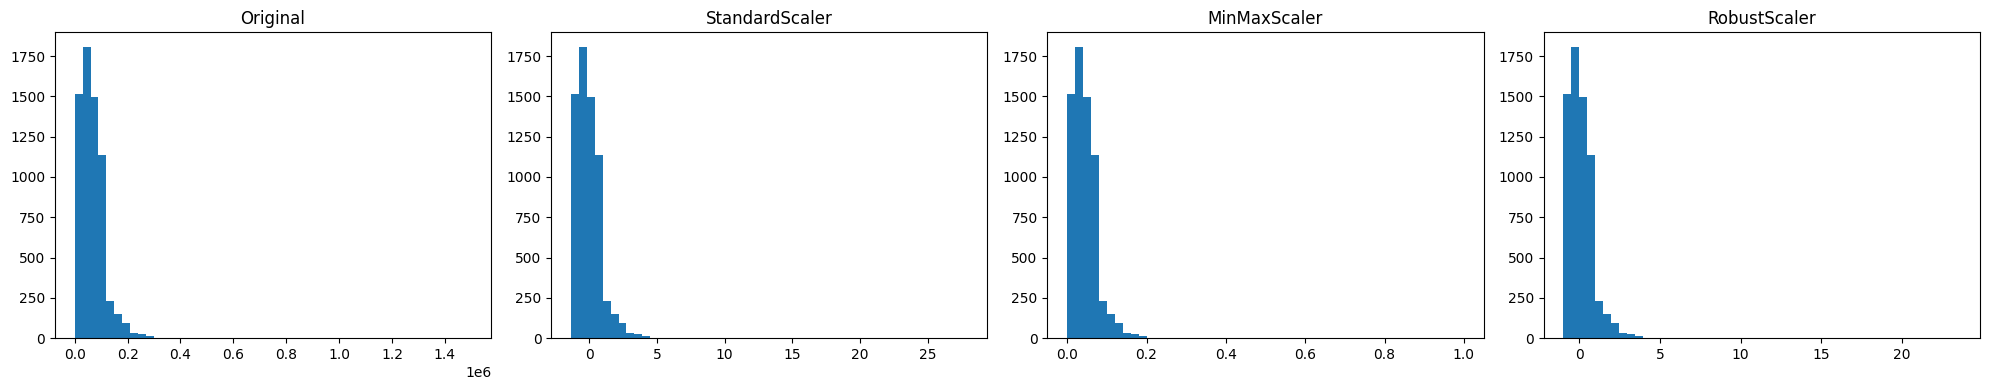

          Original  StandardScaler  MinMaxScaler  RobustScaler
count     6502.000        6502.000      6502.000      6502.000
mean     69306.269          -0.000         0.046         0.153
std      51170.618           1.000         0.034         0.839
min          1.000          -1.354         0.000        -0.984
25%      35000.000          -0.670         0.023        -0.410
50%      60000.000          -0.182         0.040         0.000
75%      96000.000           0.522         0.064         0.590
max    1500000.000          27.961         1.000        23.607
RobustScaler handles outliers best because it uses the median and IQR, so extreme km_driven values do not squeeze the bulk of the data.


In [23]:
'''Q6. Scale one skewed numeric column with StandardScaler, MinMaxScaler, and RobustScaler. Plot the three results next to the original and write one line on which handles the outliers best.'''
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

col = 'km_driven'
original = X_train[[col]]

scaled = {'Original': original.values.ravel()}
for name, sc in [('StandardScaler', StandardScaler()), ('MinMaxScaler', MinMaxScaler()), ('RobustScaler', RobustScaler())]:
    scaled[name] = sc.fit_transform(original).ravel()

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, vals) in zip(axes, scaled.items()):
    ax.hist(vals, bins=50)
    ax.set_title(name)
plt.tight_layout()
plt.show()

print(pd.DataFrame(scaled).describe().round(3))
print('RobustScaler handles outliers best because it uses the median and IQR, so extreme km_driven values do not squeeze the bulk of the data.')

In [24]:
'''Q7. Report the skewness of a skewed column, apply log1p and a Yeo-Johnson transform, and report the skewness after each.'''
from sklearn.preprocessing import PowerTransformer

col = 'km_driven'
orig = X_train[col].values

log_vals = np.log1p(orig)

pt = PowerTransformer(method='yeo-johnson').fit(X_train[[col]])
yj_vals = pt.transform(X_train[[col]]).ravel()

print('Skewness original    :', round(skew(orig), 3))
print('Skewness after log1p :', round(skew(log_vals), 3))
print('Skewness after Yeo-J :', round(skew(yj_vals), 3))

Skewness original    : 4.741
Skewness after log1p : -1.287
Skewness after Yeo-J : 0.022


In [25]:
'''Q8. Build one ColumnTransformer inside a Pipeline that performs imputing, encoding, and scaling. Fit it on train, transform test, and print both output shapes. The column counts must match.'''
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
ohe_cols = ['fuel', 'seller_type', 'transmission']
ord_cols = ['owner']
freq_cols = ['brand', 'model']

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('ohe', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), ohe_cols),
    ('ord', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=[owner_order], handle_unknown='use_encoded_value', unknown_value=-1))
    ]), ord_cols),
    ('freq', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', FrequencyEncoder())
    ]), freq_cols)
], remainder='drop')

pipe = Pipeline([('preprocess', preprocess)])

Xtr_p = pipe.fit_transform(X_train)
Xte_p = pipe.transform(X_test)

print('Train output shape:', Xtr_p.shape)
print('Test output shape :', Xte_p.shape)
assert Xtr_p.shape[1] == Xte_p.shape[1]
print('Column counts match:', Xtr_p.shape[1] == Xte_p.shape[1])

Train output shape: (6502, 18)
Test output shape : (1626, 18)
Column counts match: True


In [26]:
'''Q9. Now demonstrate leakage. Fit a scaler on the full dataset before splitting, transform the test set, and print the first five scaled values. Then do it correctly, fitting on train only, and print the same five values. Show the difference numerically and explain in three lines why the first version makes your test score a lie.'''
col = 'km_driven'

leaky_scaler = StandardScaler().fit(X[[col]])
leaky_test = leaky_scaler.transform(X_test[[col]]).ravel()

clean_scaler = StandardScaler().fit(X_train[[col]])
clean_test = clean_scaler.transform(X_test[[col]]).ravel()

print('Leaky first five  :', leaky_test[:5].round(6))
print('Correct first five:', clean_test[:5].round(6))
print('Difference        :', (leaky_test[:5] - clean_test[:5]).round(6))
print('Mean abs difference over test set:', np.abs(leaky_test - clean_test).mean())
print('Scaler mean/std on full data :', leaky_scaler.mean_[0], leaky_scaler.scale_[0])
print('Scaler mean/std on train only:', clean_scaler.mean_[0], clean_scaler.scale_[0])
print('The leaky scaler learned its mean and std from rows that include the test set, so test information shaped the preprocessing.')
print('The model is then evaluated on data that was already used to set the scale, which is not truly unseen data.')
print('So the test score is optimistic and will not hold when genuinely new data arrives in production.')

Leaky first five  : [-0.350496 -0.350496  0.74613  -1.057871  1.241098]
Correct first five: [-0.377321 -0.377321  0.83462  -1.15908   1.381636]
Difference        : [ 0.026825  0.026825 -0.08849   0.101209 -0.140538]
Mean abs difference over test set: 0.06950402552923055
Scaler mean/std on full data : 69819.51082677166 56547.076101523824
Scaler mean/std on train only: 69306.26868655799 51166.68326687192
The leaky scaler learned its mean and std from rows that include the test set, so test information shaped the preprocessing.
The model is then evaluated on data that was already used to set the scale, which is not truly unseen data.
So the test score is optimistic and will not hold when genuinely new data arrives in production.


In [27]:
'''Q10. Report the class ratio of the target. Apply SMOTE on the training set only, and print the class counts before and after. State clearly why the test set is left untouched. If the import fails, run !pip install imbalanced-learn in the first cell.'''
from imblearn.over_sampling import SMOTE

counts = y.value_counts()
print('Class counts (full data):', counts.to_dict())
print('Class ratio majority:minority = %.2f : 1' % (counts.max() / counts.min()))
print('Minority share: %.2f%%' % (100 * counts.min() / counts.sum()))

print('Before SMOTE:', Counter(y_train))
smote = SMOTE(random_state=42)
Xtr_res, ytr_res = smote.fit_resample(Xtr_p, y_train)
print('After SMOTE :', Counter(ytr_res))
print('Test set     :', Counter(y_test), '(unchanged)')
print('The test set must keep the real class distribution and only real rows, because synthetic samples there would make the score measure something that never happens in deployment.')

Class counts (full data): {0: 7258, 1: 870}
Class ratio majority:minority = 8.34 : 1
Minority share: 10.70%
Before SMOTE: Counter({0: 5806, 1: 696})
After SMOTE : Counter({0: 5806, 1: 5806})
Test set     : Counter({0: 1452, 1: 174}) (unchanged)
The test set must keep the real class distribution and only real rows, because synthetic samples there would make the score measure something that never happens in deployment.


In [28]:
'''Q11. Save the fitted pipeline with joblib.dump. In a fresh cell, load it back and transform a single new row of raw data end to end. Download the file from Colab with files.download or the file panel on the left.'''
import joblib
from google.colab import files

joblib.dump(pipe, 'preprocess_pipeline.joblib')
files.download('preprocess_pipeline.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
loaded_pipe = joblib.load('preprocess_pipeline.joblib')

new_row = pd.DataFrame([{
    'year': 2017,
    'km_driven': 45000,
    'mileage': 18.5,
    'engine': 1197,
    'max_power': 82.0,
    'seats': 5,
    'fuel': 'Petrol',
    'seller_type': 'Individual',
    'transmission': 'Manual',
    'owner': 'First Owner',
    'brand': 'Maruti',
    'model': 'Maruti Swift'
}])

out = loaded_pipe.transform(new_row)
print(out.shape)
print(out.round(4))

(1, 18)
[[ 0.7887 -0.475  -0.2248 -0.5055 -0.2575 -0.4259  0.      0.      0.
   1.      0.      1.      0.      0.      1.      1.      0.3013  0.0958]]


In [ ]:
'''Q.12 NA(Can't Solve)'''